# CBOW: Continuous Bag of Words

There are two types of Word2Vec:
1. CBOW
2. Skip-gram

The Continuous Bag of Words (CBOW) is one of the two main architectures used by Word2Vec to learn word embeddings. The fundamental goal of CBOW is to **predict a target word based on its surrounding context words.**


### How it Works: The Working Principle

In CBOW, the model "looks" at a fixed number of words before and after a target word (this is called the **window size**) and tries to guess what the middle word should be.

#### The Architecture
1.  **Input Layer:** The model takes the one-hot encoded vectors of the surrounding context words.
2.  **Hidden Layer:** The model calculates the **average** of these context word vectors. This is why it is called "Bag of Words"—the order of the context words does not matter; only their combined average is used.
3.  **Output Layer:** A softmax function is applied to predict the most likely target word from the entire vocabulary.

During training, the weights between the layers are adjusted until the model becomes accurate at predicting the target word. These weights eventually become the **Word Vectors**.


### Example Scenario

**Sentence:** "The quick brown fox jumps over the dog."
**Target Word:** "fox"
**Context Words (Window Size = 2):** ["quick", "brown", "jumps", "over"]

The model takes the vectors for "quick", "brown", "jumps", and "over," averages them, and tries to predict that the word in the middle is "fox."


### Implementation Code (Gensim)

In Gensim, you select the CBOW architecture by setting the `sg` (Skip-gram) parameter to `0`.

```python
from gensim.models import Word2Vec

# Example corpus
sentences = [
    ["the", "cat", "sat", "on", "the", "mat"],
    ["the", "dog", "ate", "my", "homework"],
    ["nlp", "is", "a", "subset", "of", "ai"]
]

# Training the CBOW model
# sg=0 means CBOW (sg=1 would be Skip-gram)
model = Word2Vec(
    sentences, 
    vector_size=100, 
    window=5, 
    min_count=1, 
    sg=0, 
    workers=4
)

# Finding similar words
print(model.wv.most_similar("cat"))


## Detailed Working of CBOW (Continuous Bag of Words)

CBOW works by using a "neighborhood" of words to predict a missing word in the middle. Let's walk through the entire process using a specific example.

### The Example Sentence:
**"The movie was very good"**

*   **Target Word:** "very"
*   **Context Words (Window Size = 1):** ["was", "good"]
*   **Vocabulary:** {The, movie, was, very, good} (Size = 5)


### Step 1: One-Hot Encoding (Input Layer)
The model converts the context words into binary vectors based on their position in the vocabulary.

*   **"was"** (Index 2): `[0, 0, 1, 0, 0]`
*   **"good"** (Index 4): `[0, 0, 0, 0, 1]`

These two vectors are the inputs to the model.


### Step 2: The Averaging Step (Hidden Layer)
The model takes all input vectors and calculates their **average**. This represents the combined meaning of the surroundings.

*   `Input 1 (was): [0, 0, 1, 0, 0]`
*   `Input 2 (good): [0, 0, 0, 0, 1]`
*   **Sum:** `[0, 0, 1, 0, 1]`
*   **Average (Hidden Layer):** `[0, 0, 0.5, 0, 0.5]`

This average vector is a single representation of the context "was ___ good".


### Step 3: Weight Multiplication
The hidden layer vector is multiplied by a **Weight Matrix (W)**. This matrix is what the model is trying to learn. This multiplication "stretches" or "squeezes" the vector to map it toward the correct target word in the vocabulary.


### Step 4: Prediction (Output Layer)
The model uses the **Softmax** function to turn the result into probabilities. It might look like this:

*   Probability of "The": 0.05
*   Probability of "movie": 0.10
*   Probability of "was": 0.05
*   **Probability of "very": 0.70** (Target)
*   Probability of "good": 0.10

The model predicts "very" because it has the highest score.


### Step 5: Learning (Backpropagation)
*   **If correct:** The model strengthens the weights that led to "very."
*   **If wrong:** (e.g., it predicted "movie"), it calculates the difference between its guess and the truth. It then goes back and slightly changes the numbers in the **Weight Matrix** so that next time it is more likely to guess "very."

**After seeing millions of sentences, the values in the Weight Matrix become so accurate at understanding relationships that we use those values as our "Word Vectors."**


### Visual Flow

```text
[ "was"  ] (1x5) --\
                    [ AVERAGE ] (1x5) --> [ WEIGHTS ] --> [ Softmax ] --> "very"
[ "good" ] (1x5) --/


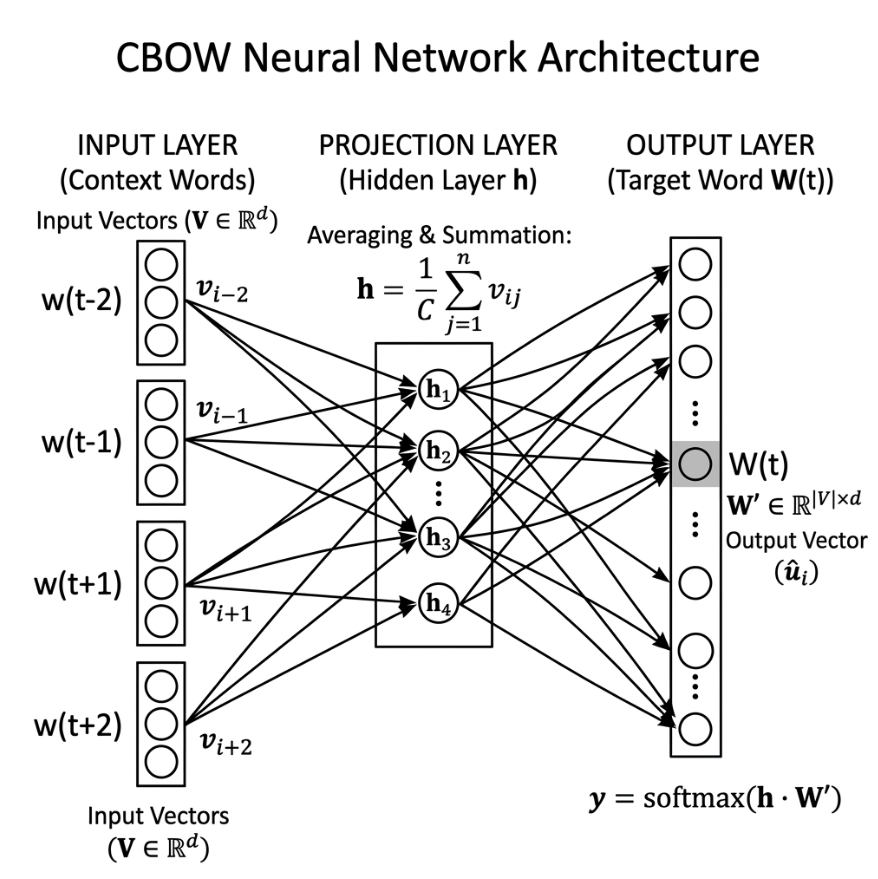

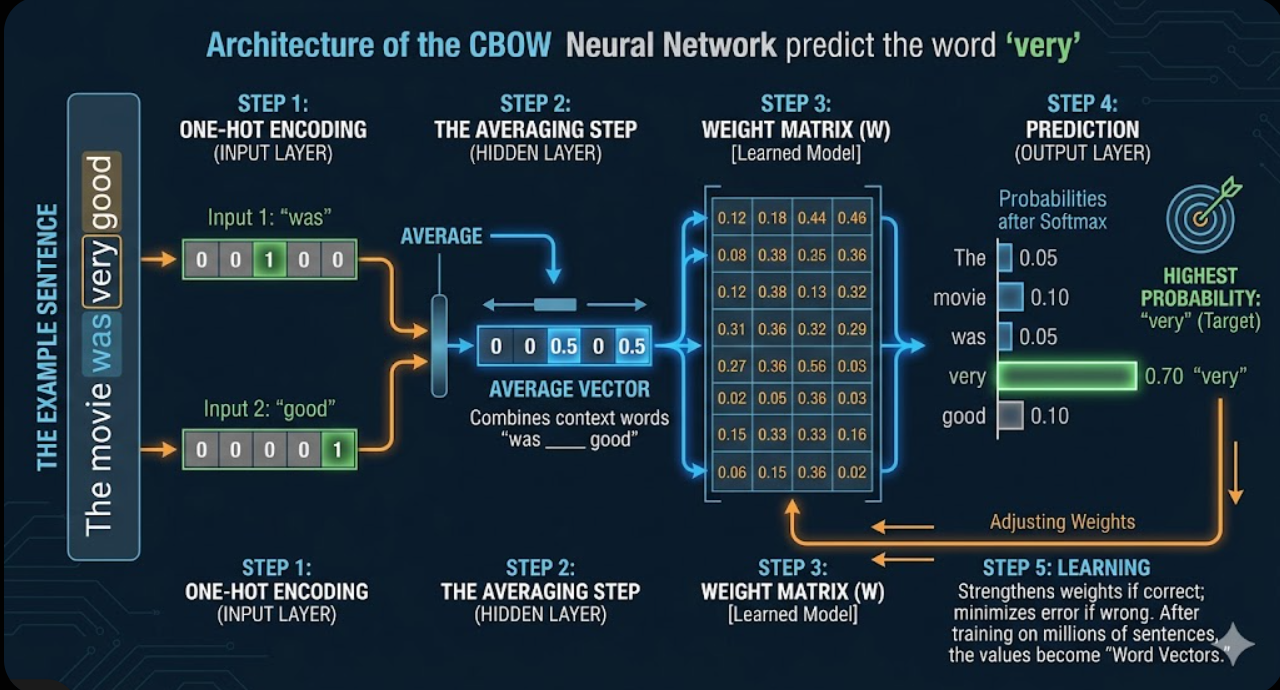